# MAISON-LLF Leakage-Safe Temporal Forecasting

This notebook predicts future SIS and OHS questionnaire items from cumulative wearable history. Each assessment becomes one example; its sensor history ends `FORECAST_GAP_DAYS` before the future `clinical-timestamp`, so sensor rows on or after the prediction horizon never enter the model.

The primary model is a small multi-task GRU with masked variable-length batches, target-specific SHAP-initialized feature gates, and attention logits biased by exponential recency decay. The decay prior favors recent days while attention remains learnable and visualizable. Patient-group splits test generalization to unseen people.

## Setup

In [1]:
from pathlib import Path
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

SEED = 2026
FORECAST_GAP_DAYS = 7
BATCH_SIZE = 12
MAX_EPOCHS = 300
PATIENCE = 45
LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 48
DROPOUT = 0.15
DECAY_RATE = 0.08
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
plt.style.use("ggplot")
DATA_DIR = Path.cwd()
FEATURES_CSV = DATA_DIR / "maison-llf-features.csv"
SIS_SHAP_CSV = DATA_DIR / "shap_sis_feature_importance.csv"
OHS_SHAP_CSV = DATA_DIR / "shap_ohs_feature_importance.csv"
DEVICE

device(type='cpu')

## Data Contract and Features

In [2]:
raw = pd.read_csv(FEATURES_CSV, parse_dates=["timestamp", "clinical-timestamp"])
raw = raw.sort_values(["participant", "timestamp", "clinical-timestamp"]).reset_index(drop=True)
sis_targets = [f"sis-{i:02d}" for i in range(1, 7)]
ohs_targets = [f"ohs-{i:02d}" for i in range(1, 13)]
target_cols = sis_targets + ohs_targets
clinical_cols = target_cols + ["sis", "ohs", "oks", "tug", "chairstand"] + [f"oks-{i:02d}" for i in range(1, 13)]
id_cols = ["participant", "timestamp", "clinical-timestamp"]
sensor_cols = [c for c in raw.columns if c not in id_cols + clinical_cols]
time_cols = ["days_since_start", "dow_sin", "dow_cos"]
input_cols = sensor_cols + time_cols

assert set(sis_targets + ohs_targets).issubset(raw.columns)
assert not set(sensor_cols).intersection(clinical_cols)
print(f"rows={len(raw)}, patients={raw['participant'].nunique()}, sensors={len(sensor_cols)}")
print(f"targets: SIS={len(sis_targets)} items, OHS={len(ohs_targets)} items")
print(sensor_cols)

rows=1008, patients=18, sensors=46
targets: SIS=6 items, OHS=12 items
['acceleration-count', 'acceleration-mean', 'acceleration-std', 'acceleration-sum', 'acceleration-entropy', 'acceleration-kurtosis', 'acceleration-skew', 'acceleration-coefficient-of-variation', 'acceleration-minutes-with-data', 'acceleration-hours-with-data', 'acceleration-movement-events-00to06', 'acceleration-movement-events-06to12', 'acceleration-movement-events-12to18', 'acceleration-movement-events-18to24', 'acceleration-movement-events-24h', 'acceleration-intradaily-variability', 'heartrate-count', 'heartrate-min', 'heartrate-max', 'heartrate-mean', 'heartrate-std', 'heartrate-hours-with-data', 'motion-count', 'motion-ratio', 'motion-mean', 'motion-max', 'motion-max-timestamp', 'position-count', 'position-duration', 'position-distance-travelled', 'sleep-total', 'sleep-deep', 'sleep-light', 'sleep-rem', 'sleep-snoring', 'sleep-duration-to-sleep', 'sleep-duration-to-wakeup', 'sleep-wakeup-count', 'sleep-heartrat

SHAP files use dataset-native names such as `sleep-snoring` and `position-distance-travelled`. Every available sensor column is retained; SHAP weights initialize feature gates where weights exist, while unlisted sensors receive a small positive prior and remain learnable.

In [3]:
def load_feature_prior(path, sensor_columns, floor=0.02):
    shap = pd.read_csv(path).dropna(subset=["feature"])
    weights = shap.set_index("feature")["weights"].astype(float).to_dict()
    prior = np.array([weights.get(c, floor) for c in sensor_columns], dtype=np.float32)
    prior = prior / prior.mean()
    return prior, shap

sis_sensor_prior, sis_shap = load_feature_prior(SIS_SHAP_CSV, sensor_cols)
ohs_sensor_prior, ohs_shap = load_feature_prior(OHS_SHAP_CSV, sensor_cols)
sis_feature_prior = np.r_[sis_sensor_prior, np.ones(len(time_cols), dtype=np.float32)]
ohs_feature_prior = np.r_[ohs_sensor_prior, np.ones(len(time_cols), dtype=np.float32)]
pd.DataFrame({"feature": sensor_cols, "sis_prior": sis_sensor_prior, "ohs_prior": ohs_sensor_prior}).sort_values("sis_prior", ascending=False).head(10)

,feature,sis_prior,ohs_prior
1,acceleration-mean,3.847972,7.295398
31,sleep-deep,3.183513,3.647503
34,sleep-snoring,2.950619,1.020264
35,sleep-duration-to-sleep,2.355552,0.608310
32,sleep-light,2.134066,0.668395
40,sleep-heartrate-max,1.863149,0.594958
24,motion-mean,1.457248,3.518694
22,motion-count,1.415423,0.575000
39,sleep-heartrate-min,1.354585,0.575000
19,heartrate-mean,1.346030,0.575000


## Future Forecast Examples

In [4]:
def add_time_features(history):
    history = history.copy()
    start = history["timestamp"].min()
    history["days_since_start"] = (history["timestamp"] - start).dt.days.astype(float)
    dow = history["timestamp"].dt.dayofweek.astype(float)
    history["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    history["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    return history

def build_forecast_examples(frame, gap_days):
    examples = []
    for patient, patient_df in frame.groupby("participant", sort=True):
        patient_df = patient_df.sort_values("timestamp")
        for clinical_time, assessment_rows in patient_df.groupby("clinical-timestamp", sort=True):
            cutoff = clinical_time - pd.Timedelta(days=gap_days)
            history = patient_df.loc[patient_df["timestamp"] <= cutoff].copy()
            if history.empty:
                continue
            history = add_time_features(history)
            target_row = assessment_rows.iloc[0]
            examples.append({
                "patient": patient,
                "clinical_time": clinical_time,
                "cutoff": cutoff,
                "timestamps": history["timestamp"].to_numpy(),
                "x_frame": history[input_cols].copy(),
                "sis": target_row[sis_targets].astype(float).to_numpy(),
                "ohs": target_row[ohs_targets].astype(float).to_numpy(),
                "sis_total": float(target_row["sis"]),
                "ohs_total": float(target_row["ohs"]),
            })
    return examples

examples = build_forecast_examples(raw, FORECAST_GAP_DAYS)
example_index = pd.DataFrame([{k: e[k] for k in ["patient", "clinical_time", "cutoff"]} | {"history_days": len(e["timestamps"])} for e in examples])
assert all(pd.Timestamp(e["timestamps"].max()) <= e["cutoff"] < e["clinical_time"] for e in examples)
assert example_index.groupby("patient")["history_days"].apply(list).eq([[7, 21, 35, 49]] * raw["participant"].nunique()).all()
example_index.head(8)

,patient,clinical_time,cutoff,history_days
0,1,2022-04-13,2022-04-06,7
1,1,2022-04-27,2022-04-20,21
2,1,2022-05-11,2022-05-04,35
3,1,2022-05-25,2022-05-18,49
4,2,2022-10-28,2022-10-21,7
5,2,2022-11-11,2022-11-04,21
6,2,2022-11-25,2022-11-18,35
7,2,2022-12-09,2022-12-02,49


Each target is predicted from a growing history with a strict one-week forecast gap. For the first patient this gives 7, 21, 35, and 49 input days for the four future assessments.

## Patient Split, Imputation, and Normalization

In [5]:
all_patients = np.array(sorted(example_index["patient"].unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(all_patients)
n_holdout_patients = max(2, math.ceil(0.34 * len(all_patients)))
n_test_patients = n_holdout_patients // 2
test_patients = all_patients[:n_test_patients]
val_patients = all_patients[n_test_patients:n_holdout_patients]
train_patients = all_patients[n_holdout_patients:]
train_ids = np.flatnonzero(example_index["patient"].isin(train_patients).to_numpy())
val_ids = np.flatnonzero(example_index["patient"].isin(val_patients).to_numpy())
test_ids = np.flatnonzero(example_index["patient"].isin(test_patients).to_numpy())

def patients_for(ids):
    return sorted(example_index.iloc[ids]["patient"].unique().tolist())

print("train patients", patients_for(train_ids))
print("val patients", patients_for(val_ids))
print("test patients", patients_for(test_ids))
assert set(patients_for(train_ids)).isdisjoint(patients_for(val_ids) + patients_for(test_ids))

train_frames = pd.concat([examples[i]["x_frame"] for i in train_ids], ignore_index=True)
train_median = train_frames.median(numeric_only=True).reindex(input_cols).fillna(0.0)
train_imputed = train_frames.reindex(columns=input_cols).fillna(train_median)
train_mean = train_imputed.mean().reindex(input_cols)
train_std = train_imputed.std(ddof=0).reindex(input_cols).replace(0, 1.0).fillna(1.0)

def transform_inputs(x_frame):
    x = x_frame.reindex(columns=input_cols).fillna(train_median)
    return ((x - train_mean) / train_std).astype(np.float32).to_numpy()

for e in examples:
    e["x"] = transform_inputs(e["x_frame"])

split_sizes = pd.Series({"train": len(train_ids), "val": len(val_ids), "test": len(test_ids)})
split_sizes

train patients [4, 5, 6, 8, 9, 11, 14, 15, 16, 17, 18]
val patients [1, 2, 3, 10]
test patients [7, 12, 13]


train    44
val      16
test     12
dtype: int64

Missing values are median-imputed from training histories only, and all input channels are standardized with training-history statistics only. Validation and test patients never influence either transform.

## Variable-Length Batches

In [6]:
class ForecastDataset(Dataset):
    def __init__(self, records, ids):
        self.records = [records[i] for i in ids]

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        e = self.records[idx]
        return {
            "x": torch.tensor(e["x"].tolist(), dtype=torch.float32),
            "sis": torch.tensor(e["sis"].tolist(), dtype=torch.float32),
            "ohs": torch.tensor(e["ohs"].tolist(), dtype=torch.float32),
            "patient": e["patient"],
            "clinical_time": e["clinical_time"],
            "timestamps": e["timestamps"],
        }

def collate_forecasts(batch):
    lengths = torch.tensor([len(b["x"]) for b in batch], dtype=torch.long)
    max_len = int(lengths.max())
    x = torch.zeros(len(batch), max_len, len(input_cols), dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)
    for i, b in enumerate(batch):
        x[i, : lengths[i]] = b["x"]
        mask[i, : lengths[i]] = True
    return {
        "x": x,
        "mask": mask,
        "lengths": lengths,
        "sis": torch.stack([b["sis"] for b in batch]),
        "ohs": torch.stack([b["ohs"] for b in batch]),
        "patient": [b["patient"] for b in batch],
        "clinical_time": [b["clinical_time"] for b in batch],
        "timestamps": [b["timestamps"] for b in batch],
    }

train_loader = DataLoader(ForecastDataset(examples, train_ids), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_forecasts)
val_loader = DataLoader(ForecastDataset(examples, val_ids), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_forecasts)
test_loader = DataLoader(ForecastDataset(examples, test_ids), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_forecasts)
batch = next(iter(train_loader))
{k: tuple(v.shape) for k, v in batch.items() if torch.is_tensor(v)}

{'x': (12, 49, 49),
 'mask': (12, 49),
 'lengths': (12,),
 'sis': (12, 6),
 'ohs': (12, 12)}

## Feature-Gated GRU With Recency-Biased Attention

In [7]:
def inverse_softplus(x):
    x = torch.tensor(np.asarray(x).tolist(), dtype=torch.float32).clamp_min(1e-4)
    return torch.log(torch.expm1(x))

class FeatureGate(nn.Module):
    def __init__(self, prior):
        super().__init__()
        self.raw = nn.Parameter(inverse_softplus(prior))

    def forward(self, x):
        weights = torch.nn.functional.softplus(self.raw)
        weights = weights / weights.mean().clamp_min(1e-6)
        return x * weights, weights

class DecayAttention(nn.Module):
    def __init__(self, hidden_dim, decay_rate):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        self.raw_decay = nn.Parameter(inverse_softplus(np.array([decay_rate], dtype=np.float32)))

    def forward(self, encoded, mask, lengths):
        steps = torch.arange(encoded.size(1), device=encoded.device).unsqueeze(0)
        age = (lengths.to(encoded.device).unsqueeze(1) - 1 - steps).clamp_min(0).float()
        decay = torch.nn.functional.softplus(self.raw_decay)
        logits = self.score(encoded).squeeze(-1) - decay * age
        logits = logits.masked_fill(~mask, -torch.finfo(encoded.dtype).max)
        attention = torch.softmax(logits, dim=1)
        context = torch.bmm(attention.unsqueeze(1), encoded).squeeze(1)
        return context, attention, decay

class MaisonTemporalForecaster(nn.Module):
    def __init__(self, n_features, sis_prior, ohs_prior, hidden_dim, dropout, decay_rate):
        super().__init__()
        self.sis_gate = FeatureGate(sis_prior)
        self.ohs_gate = FeatureGate(ohs_prior)
        self.input_projection = nn.Sequential(nn.Linear(n_features * 2, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout))
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.sis_attention = DecayAttention(hidden_dim, decay_rate)
        self.ohs_attention = DecayAttention(hidden_dim, decay_rate)
        self.sis_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, len(sis_targets)))
        self.ohs_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout), nn.Linear(hidden_dim, len(ohs_targets)))

    def forward(self, x, mask, lengths):
        sis_x, sis_weights = self.sis_gate(x)
        ohs_x, ohs_weights = self.ohs_gate(x)
        projected = self.input_projection(torch.cat([sis_x, ohs_x], dim=-1))
        packed = pack_padded_sequence(projected, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_encoded, _ = self.gru(packed)
        encoded, _ = pad_packed_sequence(packed_encoded, batch_first=True, total_length=x.size(1))
        sis_context, sis_attention, sis_decay = self.sis_attention(encoded, mask, lengths)
        ohs_context, ohs_attention, ohs_decay = self.ohs_attention(encoded, mask, lengths)
        return {
            "sis": self.sis_head(sis_context),
            "ohs": self.ohs_head(ohs_context),
            "sis_attention": sis_attention,
            "ohs_attention": ohs_attention,
            "sis_feature_weights": sis_weights,
            "ohs_feature_weights": ohs_weights,
            "sis_decay": sis_decay,
            "ohs_decay": ohs_decay,
        }

model = MaisonTemporalForecaster(len(input_cols), sis_feature_prior, ohs_feature_prior, HIDDEN_DIM, DROPOUT, DECAY_RATE).to(DEVICE)
sum(p.numel() for p in model.parameters() if p.requires_grad)

24936

The sequences are padded only inside a batch and masks remove padded days from attention. The GRU consumes packed lengths, so padding does not update recurrent state. SHAP priors enter as positive trainable feature gates. Attention combines learned content logits with a learned exponential recency penalty `-decay * age_in_days`.

## Train

In [8]:
loss_fn = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def move_batch(batch):
    return {k: v.to(DEVICE) if torch.is_tensor(v) else v for k, v in batch.items()}

def multitask_loss(output, batch):
    return loss_fn(output["sis"], batch["sis"]) + loss_fn(output["ohs"], batch["ohs"])

def run_epoch(loader, training):
    model.train(training)
    total = 0.0
    n = 0
    for batch in loader:
        batch = move_batch(batch)
        with torch.set_grad_enabled(training):
            output = model(batch["x"], batch["mask"], batch["lengths"])
            loss = multitask_loss(output, batch)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total += loss.item() * len(batch["x"])
        n += len(batch["x"])
    return total / n

history = []
best_state = copy.deepcopy(model.state_dict())
best_val = float("inf")
wait = 0
for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
    if wait >= PATIENCE:
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
print(f"epochs={len(history_df)}, best_val={best_val:.4f}")
sis_decay = torch.nn.functional.softplus(model.sis_attention.raw_decay.detach()).item()
ohs_decay = torch.nn.functional.softplus(model.ohs_attention.raw_decay.detach()).item()
print(f"learned decay: SIS={sis_decay:.4f}, OHS={ohs_decay:.4f}")
history_df.tail()

epochs=52, best_val=1.2018
learned decay: SIS=0.0781, OHS=0.0766


,epoch,train_loss,val_loss
47,48,0.344050,1.572588
48,49,0.319757,1.528342
49,50,0.327427,1.535754
50,51,0.325605,1.535153
51,52,0.307797,1.534086


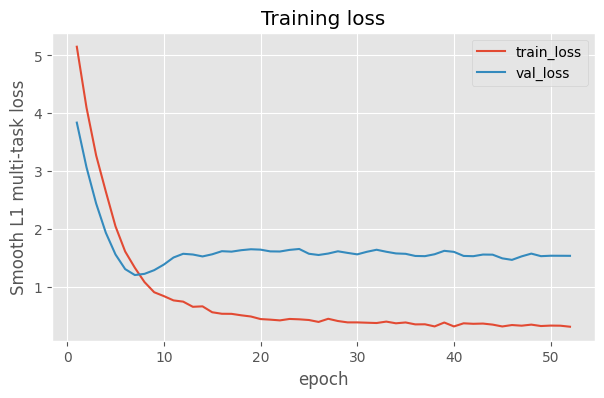

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
history_df.plot(x="epoch", y=["train_loss", "val_loss"], ax=ax)
ax.set_ylabel("Smooth L1 multi-task loss")
ax.set_title("Training loss")
plt.show()

## Evaluation

In [10]:
def collect_predictions(loader):
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            device_batch = move_batch(batch)
            output = model(device_batch["x"], device_batch["mask"], device_batch["lengths"])
            sis_pred = output["sis"].cpu().tolist()
            ohs_pred = output["ohs"].cpu().tolist()
            for i in range(len(batch["patient"])):
                base = {"patient": batch["patient"][i], "clinical_time": pd.Timestamp(batch["clinical_time"][i]), "history_days": int(batch["lengths"][i])}
                for name, truth, pred in zip(sis_targets, batch["sis"][i].tolist(), sis_pred[i]):
                    rows.append(base | {"outcome": "SIS", "item": name, "truth": float(truth), "prediction": float(pred)})
                for name, truth, pred in zip(ohs_targets, batch["ohs"][i].tolist(), ohs_pred[i]):
                    rows.append(base | {"outcome": "OHS", "item": name, "truth": float(truth), "prediction": float(pred)})
    return pd.DataFrame(rows)

test_predictions = collect_predictions(test_loader)
test_predictions.head()

,patient,clinical_time,history_days,outcome,item,truth,prediction
0,7,2024-03-07,7,SIS,sis-01,5.0,3.912827
1,7,2024-03-07,7,SIS,sis-02,5.0,3.442947
2,7,2024-03-07,7,SIS,sis-03,5.0,3.221092
3,7,2024-03-07,7,SIS,sis-04,4.0,3.805756
4,7,2024-03-07,7,SIS,sis-05,4.0,3.217991


In [11]:
def regression_metrics(frame):
    y = frame["truth"].to_numpy()
    p = frame["prediction"].to_numpy()
    pearson = np.corrcoef(y, p)[0, 1] if len(y) > 1 and np.std(y) > 0 and np.std(p) > 0 else np.nan
    residual = y - p
    sst = np.square(y - y.mean()).sum()
    r2 = 1 - np.square(residual).sum() / sst if sst > 0 else np.nan
    return pd.Series({"n": len(frame), "MAE": np.abs(residual).mean(), "RMSE": np.sqrt(np.square(residual).mean()), "R2": r2, "Pearson": pearson})

def grouped_metrics(frame, group_cols):
    rows = []
    for keys, group in frame.groupby(group_cols):
        keys = keys if isinstance(keys, tuple) else (keys,)
        rows.append(dict(zip(group_cols, keys)) | regression_metrics(group).to_dict())
    return pd.DataFrame(rows).set_index(group_cols)

overall_metrics = grouped_metrics(test_predictions, ["outcome"])
item_metrics = grouped_metrics(test_predictions, ["outcome", "item"])
patient_metrics = grouped_metrics(test_predictions, ["patient", "outcome"])
display(overall_metrics)
display(item_metrics)
display(patient_metrics)

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,144.0,0.921001,1.074907,-0.056808,0.094754
SIS,72.0,1.051230,1.172744,-0.084861,0.527375


n       MAE      RMSE        R2   Pearson
outcome item                                                
OHS     ohs-01  12.0  0.811186  0.995961 -0.373452  0.055404
        ohs-02  12.0  1.227811  1.302178 -0.298808  0.229947
        ohs-03  12.0  1.309209  1.388620  0.035867  0.287682
        ohs-04  12.0  0.799161  0.976253 -0.047649 -0.495658
        ohs-05  12.0  0.676668  0.822987  0.088484  0.458501
        ohs-06  12.0  0.516377  0.576849  0.060458  0.358879
        ohs-07  12.0  1.460029  1.524047 -2.125904  0.261966
        ohs-08  12.0  0.957170  1.174229 -0.551166 -0.789650
        ohs-09  12.0  0.787586  0.991539 -0.072527 -0.130498
        ohs-10  12.0  0.752968  0.778800  0.289916  0.946353
        ohs-11  12.0  0.874280  1.064913 -0.246577 -0.215575
        ohs-12  12.0  0.879562  0.927819 -0.252142 -0.441206
SIS     sis-01  12.0  0.937695  1.025513 -1.704315 -0.574533
        sis-02  12.0  0.985503  1.073445 -4.185278  0.439495
        sis-03  12.0  1.038288  1.151792 -2.237864  0.462488
        sis-04  12.0  0.865301  1.043273 -3.478066 -0.754857
        sis-05  12.0  1.152752  1.264623  0.024174  0.180214
        sis-06  12.0  1.327842  1.426078  0.158470  0.684824

n       MAE      RMSE        R2   Pearson
patient outcome                                              
7       OHS      48.0  0.868818  1.034736 -0.408819 -0.181437
        SIS      24.0  0.924858  1.138501  0.134876  0.390137
12      OHS      48.0  0.941262  1.084018 -0.008726  0.129310
        SIS      24.0  1.152246  1.203939 -6.730504  0.663846
13      OHS      48.0  0.952923  1.104764 -0.033837  0.144817
        SIS      24.0  1.076587  1.174876 -0.005149  0.644632

,n,MAE,RMSE,R2,Pearson
outcome,,,,,
OHS,12.0,3.804428,4.369875,-0.031045,0.350165
SIS,12.0,4.656653,5.124758,-0.998886,0.579968


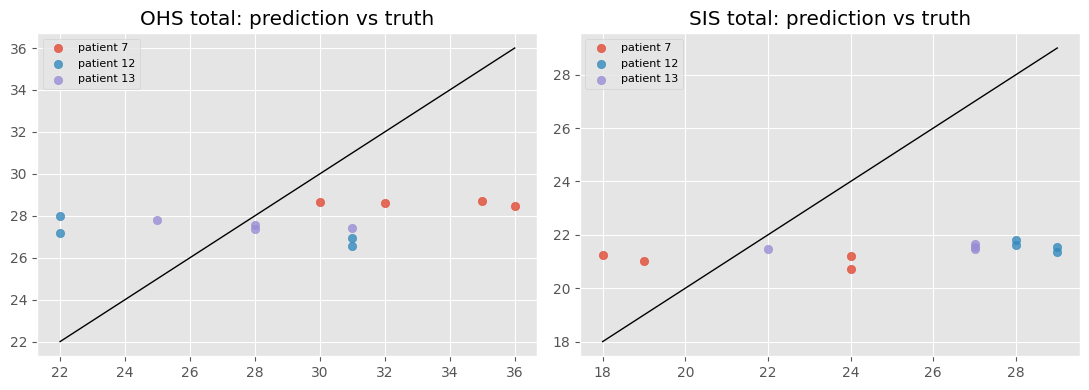

In [12]:
total_predictions = test_predictions.groupby(["patient", "clinical_time", "history_days", "outcome"], as_index=False)[["truth", "prediction"]].sum()
total_metrics = grouped_metrics(total_predictions, ["outcome"])
display(total_metrics)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (outcome, frame) in zip(axes, total_predictions.groupby("outcome")):
    for patient, patient_frame in frame.groupby("patient"):
        ax.scatter(patient_frame["truth"], patient_frame["prediction"], label=f"patient {patient}", alpha=0.8)
    lo = min(frame["truth"].min(), frame["prediction"].min())
    hi = max(frame["truth"].max(), frame["prediction"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set_title(f"{outcome} total: prediction vs truth")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Item-level metrics match the multi-output training objective. Totals are reconstructed by summing predicted questionnaire items for a clinical-score view.

## Attention and Feature Weights

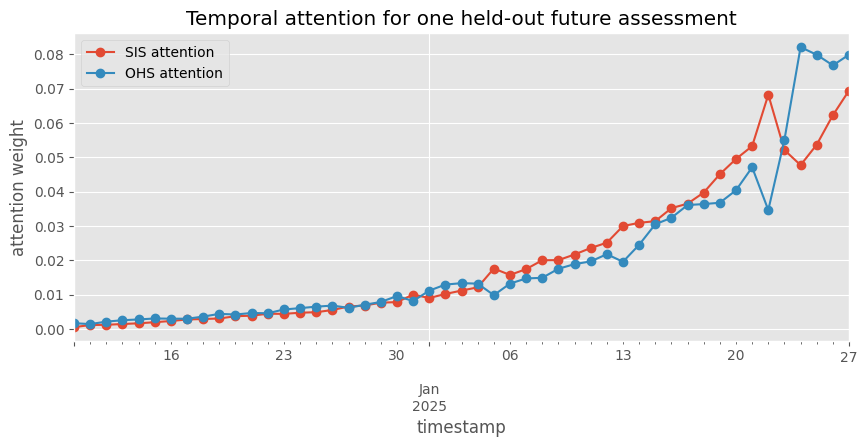

In [13]:
def attention_for_record(record):
    batch = collate_forecasts([ForecastDataset([record], [0])[0]])
    device_batch = move_batch(batch)
    model.eval()
    with torch.no_grad():
        output = model(device_batch["x"], device_batch["mask"], device_batch["lengths"])
    return pd.DataFrame({
        "timestamp": pd.to_datetime(record["timestamps"]),
        "SIS attention": output["sis_attention"][0, : len(record["timestamps"])].cpu().tolist(),
        "OHS attention": output["ohs_attention"][0, : len(record["timestamps"])].cpu().tolist(),
    })

attention_df = attention_for_record(examples[int(test_ids[-1])])
fig, ax = plt.subplots(figsize=(10, 4))
attention_df.set_index("timestamp")[["SIS attention", "OHS attention"]].plot(ax=ax, marker="o")
ax.set_title("Temporal attention for one held-out future assessment")
ax.set_ylabel("attention weight")
plt.show()

In [14]:
with torch.no_grad():
    sis_learned = np.array(torch.nn.functional.softplus(model.sis_gate.raw).cpu().tolist())
    ohs_learned = np.array(torch.nn.functional.softplus(model.ohs_gate.raw).cpu().tolist())
learned_weights = pd.DataFrame({"feature": input_cols, "SIS learned weight": sis_learned / sis_learned.mean(), "OHS learned weight": ohs_learned / ohs_learned.mean()})
display(learned_weights.sort_values("SIS learned weight", ascending=False).head(12))
display(learned_weights.sort_values("OHS learned weight", ascending=False).head(12))

,feature,SIS learned weight,OHS learned weight
1,acceleration-mean,3.833736,7.238600
31,sleep-deep,3.200160,3.649855
34,sleep-snoring,2.975048,1.020081
35,sleep-duration-to-sleep,2.373974,0.622558
32,sleep-light,2.110758,0.666154
40,sleep-heartrate-max,1.872597,0.598304
24,motion-mean,1.462551,3.505116
22,motion-count,1.390555,0.578363
19,heartrate-mean,1.352866,0.585887
39,sleep-heartrate-min,1.343012,0.587722


,feature,SIS learned weight,OHS learned weight
1,acceleration-mean,3.833736,7.238600
31,sleep-deep,3.200160,3.649855
24,motion-mean,1.462551,3.505116
23,motion-ratio,0.634503,2.260971
25,motion-max,0.538042,1.923773
26,motion-max-timestamp,1.191070,1.616877
43,step-mean,0.643614,1.176039
38,sleep-heartrate-mean,0.629682,1.038197
47,dow_sin,1.011427,1.023765
48,dow_cos,1.023078,1.021107


## Research Notes

- This is a patient-held-out small-sample experiment. Report patient IDs, uncertainty, and fold variation before clinical claims.
- For cross-validation, repeat the same grouped split logic with several patient folds and fit imputation and scaling inside each fold.
- The architecture can be replaced by a masked temporal transformer after the sample-construction and transform cells; those cells define the leakage boundary.